In [1]:
import matplotlib.pyplot as plt
from pdf2image import convert_from_path

In [2]:
DATA_PATH = "C:/Users/patri/Documents/Learning Sources/github/locallm/data/pdfs/pav/"

In [3]:
PDFs = [
    {'title': "extract"},
]


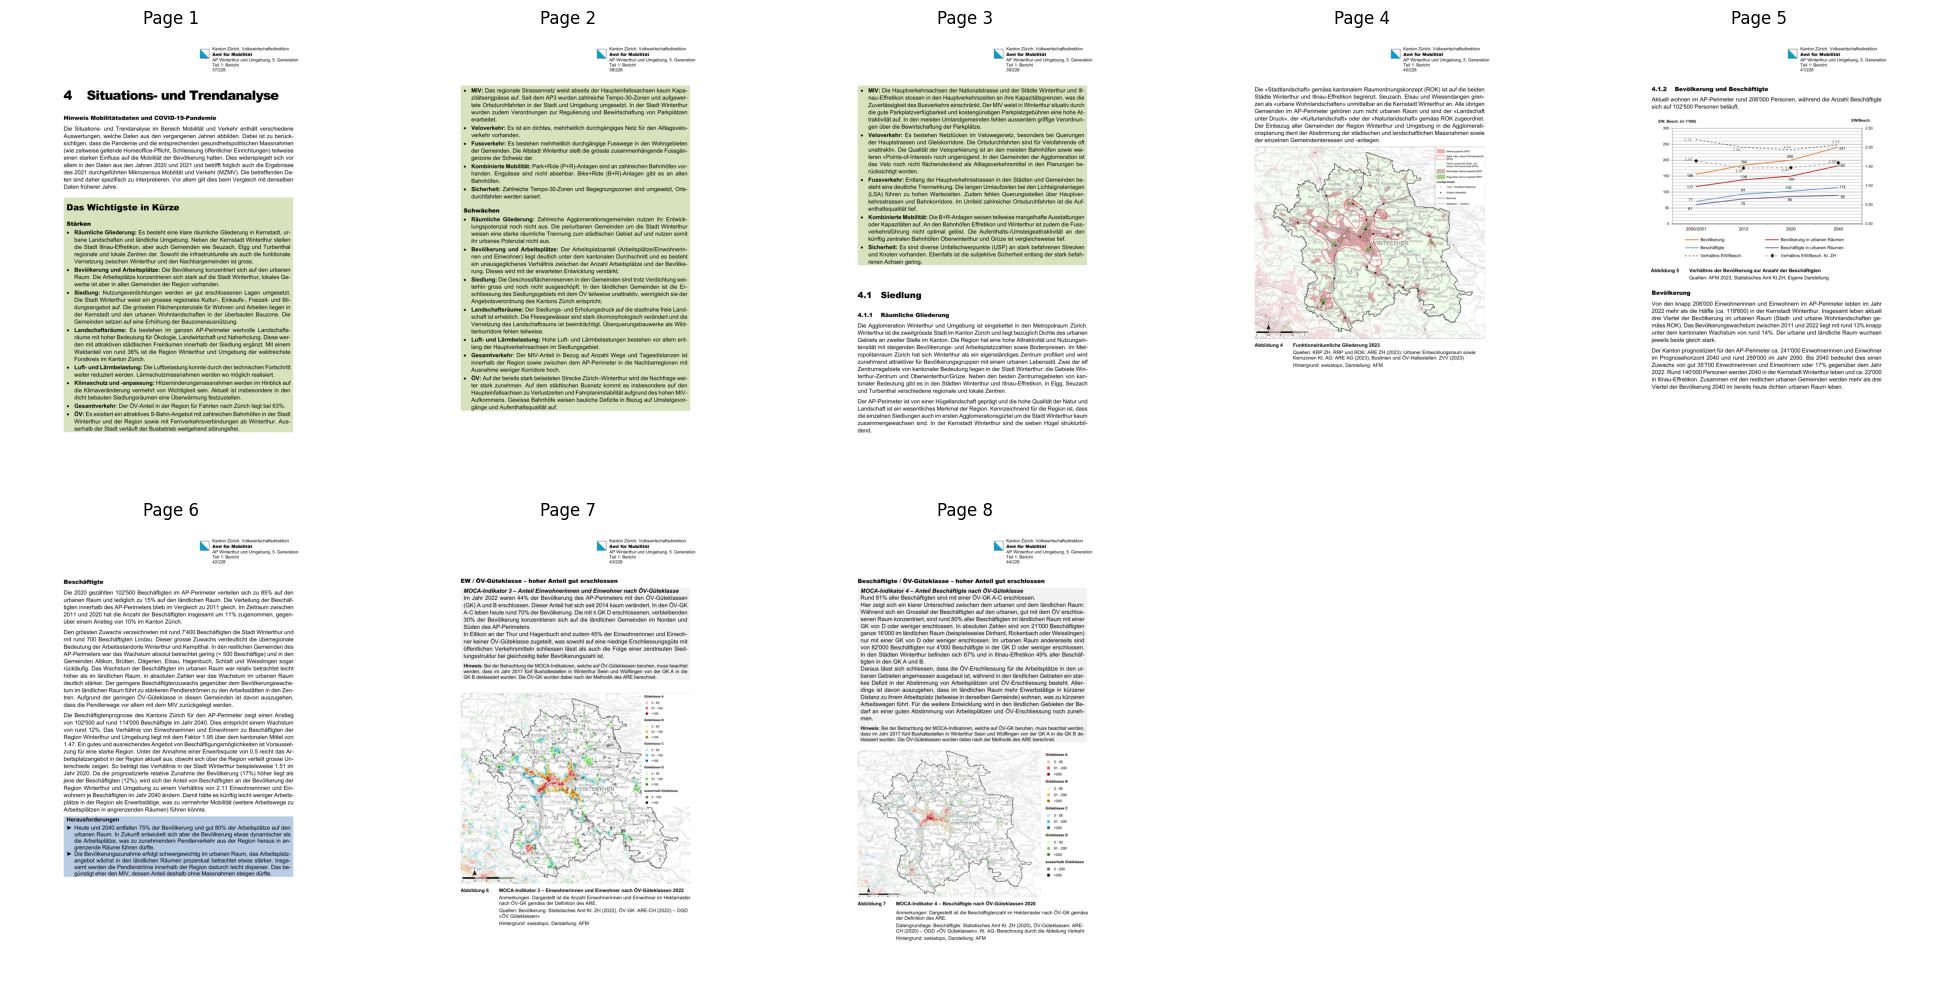

In [4]:
def display_pdf_images(images_list, n: int = 5):
    """Display all images in the provided list as subplots with n images per row"""
    num_images = len(images_list)
    num_rows = num_images // n + (1 if num_images % n > 0 else 0)
    fig, axs = plt.subplots(num_rows, n, figsize=(20, 5 * num_rows))
    axs = axs.flatten()
    for i, img in enumerate(images_list):
        if i < len(axs):
            ax = axs[i]
            ax.imshow(img)
            ax.set_title(f"Page {i+1}")
            ax.axis("off")
    for j in range(num_images, len(axs)):
        axs[j].axis("off")
    plt.tight_layout()
    plt.show()

for pdf in PDFs:
    pdf["images"] = convert_from_path(DATA_PATH + f"{pdf["title"]}.pdf")
display_pdf_images(PDFs[0]["images"], 5)

In [5]:
from colpali_engine.models import BiQwen2_5, BiQwen2_5_Processor
import torch

nomic_model = BiQwen2_5.from_pretrained(
    "nomic-ai/nomic-embed-multimodal-3b",
    torch_dtype = torch.float32
).eval()

nomic_processor = BiQwen2_5_Processor.from_pretrained("nomic-ai/nomic-embed-multimodal-3b")

c:\Users\patri\miniconda3\envs\locallm\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading checkpoint shards: 100%|██████████| 2/2 [00:45<00:00, 22.51s/it]
Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
You have video processor config saved in `preprocessor.json` file which is deprecated. Video processor configs should be saved in their own `video_preprocessor.json` file. You can rename the file or load and save the processor back which renames it automatically. Loading from `preprocessor.json` will be removed in v5.0.


In [6]:
image_counter = 0
for pdf_idx, pdf in enumerate(PDFs):
    print(f"Generating embeddings for {len(pdf['images'])} pages in {pdf['title']}")
    pdf['page_embeddings'] = []
    batch_size = 4
    for i in range(0, len(pdf["images"]), batch_size):
        batch_images = pdf["images"][i:i+batch_size]
        inputs = nomic_processor.process_images(batch_images)
        inputs = {k: v.to(nomic_model.device) for k, v in inputs.items()}
        with torch.no_grad():
            embeddings = nomic_model(**inputs)
        embeddings = embeddings.cpu()
        embeddings = embeddings / torch.norm(embeddings, dim=1, keepdim=True)
        for j, emb in enumerate(embeddings):
            if i+j < len(pdf["images"]):
                if 'page_embeddings' not in pdf:
                    pdf['page_embeddings'] = []
                pdf['page_embeddings'].append(emb)
                image_counter += 1

print(f"Generated embeddings for {image_counter} PDF pages")

Generating embeddings for 8 pages in extract
Generated embeddings for 8 PDF pages


In [7]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

embeddings = np.stack([
    embedding.float().numpy()
    for pdf in PDFs for embedding in pdf["page_embeddings"]
])

data = []
page_count = 0
for pdf in PDFs:
    for page_idx in range(len(pdf["images"])):
        data.append({
            "title": pdf["title"],
            "page_number": page_idx + 1,
            "image": pdf["images"][page_idx],
            "id": page_count
        })
        page_count += 1

def retrieve(query: str, k: int = 3) -> list:
    """Retrieve semantically similar items from data based on embeddings"""
    query = nomic_processor.process_queries([query])
    with torch.no_grad():
        query = {k: v.to(nomic_model.device) for k, v in query.items()}
        query_embedding = nomic_model(**query).float().cpu().numpy()
    query_embedding = query_embedding / np.linalg.norm(query_embedding)
    cos_sim = cosine_similarity(query_embedding, embeddings)[0]
    idx_sorted_by_cosine_sim = np.argsort(cos_sim)[::-1]
    sorted_data = [data[i] for i in idx_sorted_by_cosine_sim]
    return sorted_data[:k]

In [8]:
from transformers import Qwen2_5_VLForConditionalGeneration, AutoProcessor
from qwen_vl_utils import process_vision_info
from PIL import Image

model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    "Qwen/Qwen2.5-VL-3B-Instruct",
    torch_dtype = torch.float32
)

processor = AutoProcessor.from_pretrained("Qwen/Qwen2.5-VL-3B-Instruct")

def query_vlm(query: str, images: list[Image]) -> str:
    """Queries Qwen VLM with text and images"""
    
    system_prompt = "You are an expert professional PDF analyst who gives rigorous in-depth answers."
    
    message_content = [
        {"type": "image", "image": image}
        for image in images
    ] + [{"type": "text", "text": query}]
    
    messages = [
        {
            "role": "system",
            "content": [{"type": "text", "text": system_prompt}]
        },
        {
            "role": "user",
            "content": message_content
        }
    ]
    
    text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    
    image_inputs, video_inputs = process_vision_info(messages)
    
    inputs = processor(
        text=[text],
        images=image_inputs,
        videos=video_inputs,
        padding=True,
        return_tensors="pt"
    ).to(model.device)
    
    generated_ids = model.generate(**inputs, max_new_tokens=512)
    
    generated_ids_trimmed = generated_ids[0][len(inputs.input_ids[0]):]
    
    return processor.decode(generated_ids_trimmed, skip_special_tokens=True)

Loading checkpoint shards: 100%|██████████| 2/2 [00:37<00:00, 18.79s/it]


In [ ]:
query = "Aus welcher Stadt stammt das Agglomerationsprogramm?"
results = retrieve(query, k=1)
image = results[0]["image"]
display(image)
print("--- start querying ---")
single_doc_answer = query_vlm(query, [image])
print(single_doc_answer)

NameError: name 'retrieve' is not defined